In [1]:
# # === STEP 1: Import Libraries ===
# import pandas as pd
# import sqlite3
# import seaborn as sns
# import matplotlib.pyplot as plt
# from datetime import datetime

In [2]:
# # === STEP 2: Connect to the Database ===
# conn = sqlite3.connect("stackoverflow.db")

In [3]:
# # === STEP 3: Load and Preview 'posts' Table ===
# posts_df = pd.read_sql_query("SELECT * FROM posts", conn)

In [4]:
# # === STEP 3: Load Only Required Columns from 'posts' Table ===
# query = """
#     SELECT Id, CreationDate
#     FROM posts
#     WHERE CreationDate IS NOT NULL
# """
# posts_df = pd.read_sql_query(query, conn)

# print(f"Loaded rows: {len(posts_df)}")
# print(posts_df.head())

In [5]:
# print(f"Number of rows in 'posts': {len(posts_df)}")
# print(posts_df.head())
# print(posts_df.dtypes)

In [6]:
# # === STEP 4: Clean Data ===
# posts_df["CreationDate"] = pd.to_datetime(posts_df["CreationDate"], errors="coerce")
# posts_df = posts_df.dropna(subset=["CreationDate"])
# posts_df = posts_df[posts_df["CreationDate"] <= pd.Timestamp(datetime.today())]
# posts_df = posts_df.drop_duplicates(subset=["Id"])

In [7]:
# # === STEP 5: Extract Year-Month from CreationDate ===
# posts_df["YearMonth"] = posts_df["CreationDate"].dt.to_period("M").astype(str)

In [8]:
# # === STEP 6: Group by Year-Month and Count Posts ===
# monthly_posts = posts_df.groupby("YearMonth").size().reset_index(name="PostCount")

In [9]:
# # === STEP 7: Create Bar Plot with Grouped Year Labels ===
# plt.figure(figsize=(12, 6))
# ax = sns.barplot(x="YearMonth", y="PostCount", data=monthly_posts, palette="viridis")

# plt.title("Number of Posts per Year-Month")
# plt.xlabel("Year-Month")
# plt.ylabel("Post Count")
# plt.xticks(rotation=90, ha='right')

# # Grouped labels like in previous charts
# year_month_pattern = []
# unique_years = monthly_posts["YearMonth"].str.split("-").str[0].unique()

# for year in unique_years:
#     year_month_pattern.append(year)
#     year_month_pattern.extend([' '] * (monthly_posts["YearMonth"].str.startswith(year).sum() - 1))

# ax.set_xticklabels(year_month_pattern)

# plt.tight_layout()
# plt.show()

In [10]:
# === STEP 1: Import Libraries ===
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

In [11]:
# === STEP 2: Connect to the Database ===
conn = sqlite3.connect("stackoverflow.db")

Engagement Metric – Posts Per Month (1M rows). Then to 5M rows.

In [12]:
# === STEP 3: Load Only 1M Rows of Posts with Required Columns ===
query = """
    SELECT Id, CreationDate
    FROM posts
    WHERE CreationDate IS NOT NULL
    LIMIT 5000000
"""
posts_df = pd.read_sql_query(query, conn)

In [13]:
print(f"Loaded rows: {len(posts_df)}")
print(posts_df.head())

Loaded rows: 5000000
   Id             CreationDate
0   4  2008-07-31T21:42:52.667
1   6  2008-07-31T22:08:08.620
2   7  2008-07-31T22:17:57.883
3   9  2008-07-31T23:40:59.743
4  11  2008-07-31T23:55:37.967


In [14]:
# === STEP 4: Clean & Process Dates ===
posts_df["CreationDate"] = pd.to_datetime(posts_df["CreationDate"], errors="coerce")
posts_df = posts_df.dropna(subset=["CreationDate"])
posts_df = posts_df[posts_df["CreationDate"] <= pd.Timestamp(datetime.today())]
posts_df = posts_df.drop_duplicates(subset=["Id"])

In [15]:
# === STEP 5: Extract Year-Month ===
posts_df["YearMonth"] = posts_df["CreationDate"].dt.to_period("M").astype(str)

In [16]:
# === STEP 6: Group by Year-Month and Count Posts ===
monthly_posts = posts_df.groupby("YearMonth").size().reset_index(name="PostCount")

C:\Users\Ola\AppData\Local\Temp\ipykernel_328\1599078958.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="YearMonth", y="PostCount", data=monthly_posts, palette="viridis")
C:\Users\Ola\AppData\Local\Temp\ipykernel_328\1599078958.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(year_month_pattern)


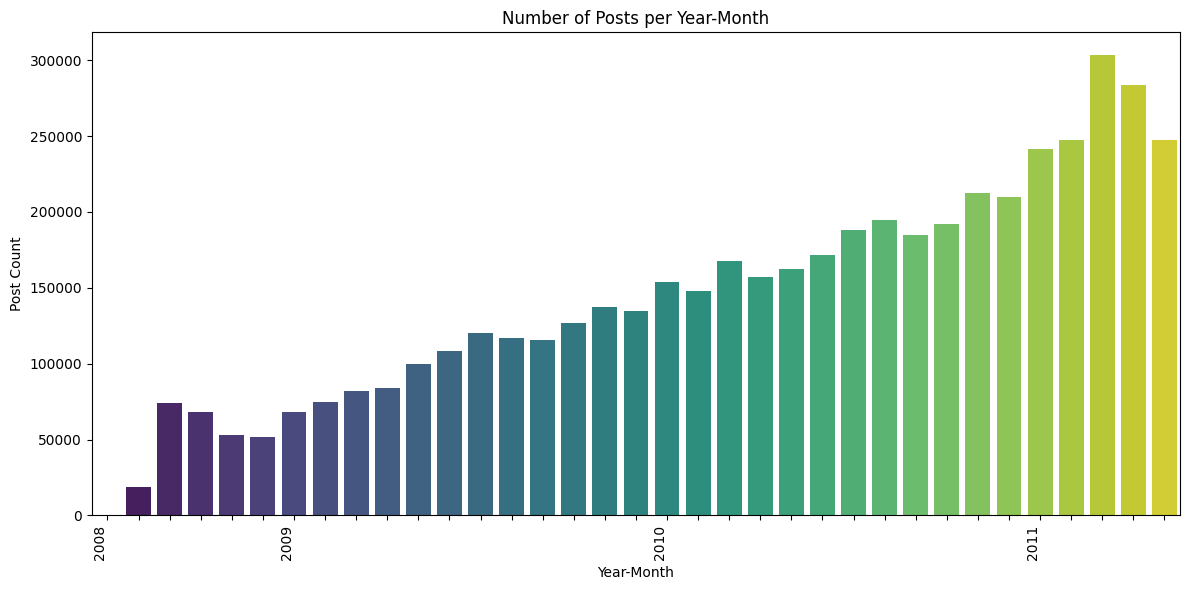

In [17]:
# === STEP 7: Create Bar Plot with Grouped Year Labels ===
plt.figure(figsize=(12, 6))
ax = sns.barplot(x="YearMonth", y="PostCount", data=monthly_posts, palette="viridis")

plt.title("Number of Posts per Year-Month")
plt.xlabel("Year-Month")
plt.ylabel("Post Count")
plt.xticks(rotation=90, ha='right')

# Grouped year labels
year_month_pattern = []
unique_years = monthly_posts["YearMonth"].str.split("-").str[0].unique()

for year in unique_years:
    year_month_pattern.append(year)
    year_month_pattern.extend([' '] * (monthly_posts["YearMonth"].str.startswith(year).sum() - 1))

ax.set_xticklabels(year_month_pattern)

plt.tight_layout()
plt.show()

Engagement Metric – Comments Per Month (1M rows). Then to 5M rows.

In [18]:
# === STEP 3: Load Only 1M Rows of Comments with Required Columns ===
query = """
    SELECT Id, CreationDate
    FROM comments
    WHERE CreationDate IS NOT NULL
    LIMIT 5000000
"""
comments_df = pd.read_sql_query(query, conn)

In [19]:
print(f"Loaded rows: {len(comments_df)}")
print(comments_df.head())

Loaded rows: 5000000
   Id             CreationDate
0  10  2008-09-06T13:38:23.647
1  12  2008-09-06T13:51:47.843
2  14  2008-09-06T14:15:46.897
3  15  2008-09-06T14:30:40.217
4  16  2008-09-06T14:42:35.303


In [20]:
# === STEP 4: Clean & Process Dates ===
comments_df["CreationDate"] = pd.to_datetime(comments_df["CreationDate"], errors="coerce")
comments_df = comments_df.dropna(subset=["CreationDate"])
comments_df = comments_df[comments_df["CreationDate"] <= pd.Timestamp(datetime.today())]
comments_df = comments_df.drop_duplicates(subset=["Id"])

In [21]:
# === STEP 5: Extract Year-Month ===
comments_df["YearMonth"] = comments_df["CreationDate"].dt.to_period("M").astype(str)

In [22]:
# === STEP 6: Group by Year-Month and Count Comments ===
monthly_comments = comments_df.groupby("YearMonth").size().reset_index(name="CommentCount")

C:\Users\Ola\AppData\Local\Temp\ipykernel_328\3538676491.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="YearMonth", y="CommentCount", data=monthly_comments, palette="viridis")
C:\Users\Ola\AppData\Local\Temp\ipykernel_328\3538676491.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(year_month_pattern)


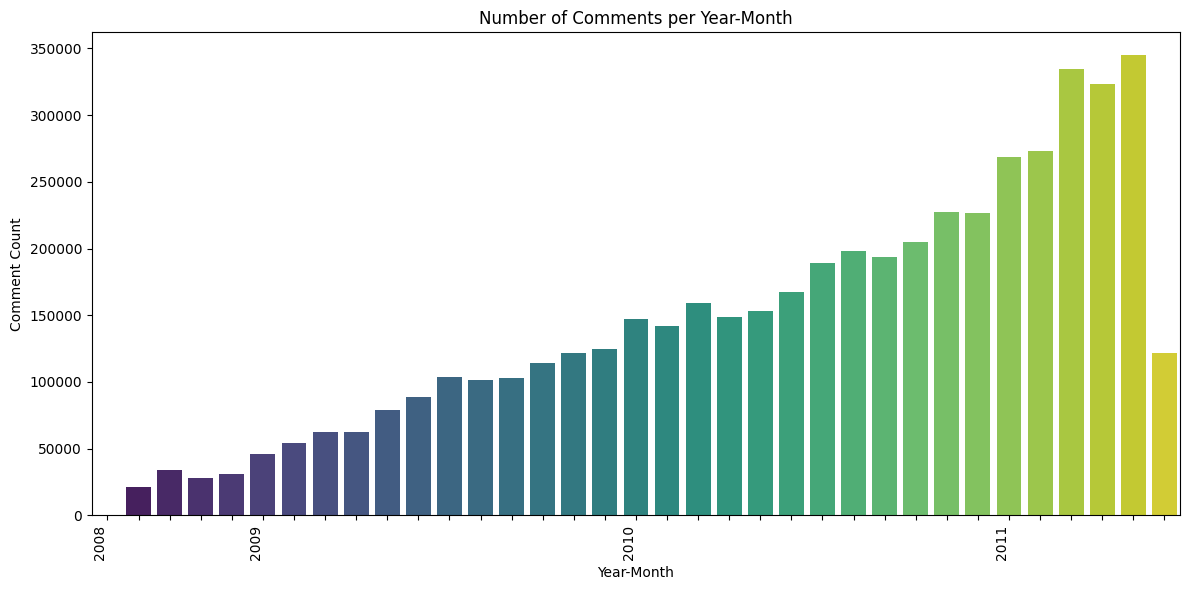

In [23]:
# === STEP 7: Create Bar Plot with Grouped Year Labels ===
plt.figure(figsize=(12, 6))
ax = sns.barplot(x="YearMonth", y="CommentCount", data=monthly_comments, palette="viridis")

plt.title("Number of Comments per Year-Month")
plt.xlabel("Year-Month")
plt.ylabel("Comment Count")
plt.xticks(rotation=90, ha='right')

# Grouped year labels
year_month_pattern = []
unique_years = monthly_comments["YearMonth"].str.split("-").str[0].unique()

for year in unique_years:
    year_month_pattern.append(year)
    year_month_pattern.extend([' '] * (monthly_comments["YearMonth"].str.startswith(year).sum() - 1))

ax.set_xticklabels(year_month_pattern)

plt.tight_layout()
plt.show()
